# Feature Engineering & Signal Generation Notebook

**Phase 1, Day 8: Research Infrastructure**

This notebook demonstrates:
1. Loading real market data (EURUSD daily)
2. Computing features using FeatureLibrary
3. Statistical analysis of features
4. Stationarity testing
5. Basic signal generation
6. Visualization and interpretation

Goals:
- Generate 10+ candidate features from real FX data
- Analyze feature distributions
- Test stationarity (ADF test)
- Evaluate signal quality

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import stats

# Import custom modules
import sys
sys.path.insert(0, '/home/ghost/fx-quant-research/src')
from features.returns import (
    compute_log_returns, 
    compute_rolling_volatility, 
    compute_zscore,
    compute_returns_comparison,
    annualize_volatility
)
from features.library import FeatureLibrary

# Setup plotting
plt.rcParams['figure.figsize'] = (14, 6)

## Section 1: Load Real Market Data

Load EURUSD daily price data from CSV file for feature engineering.

In [ ]:
print("=" * 80)
print("SECTION 1: LOAD REAL MARKET DATA (EURUSD DAILY)")
print("=" * 80)

# Load real EURUSD daily data from CSV
data_path = '/home/ghost/fx-quant-research/data/raw/EURUSD_daily.csv'
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

# Extract close prices as our price series
price_series = df['close'].copy()
price_series.name = 'EURUSD_Close'

print(f"\nPrice Data Summary:")
print(f"  Symbol: EURUSD")
print(f"  Timeframe: Daily")
print(f"  Period: {df.index[0].date()} to {df.index[-1].date()}")
print(f"  Number of observations: {len(price_series):,}")
print(f"  Duration: {(df.index[-1] - df.index[0]).days / 365.25:.1f} years")
print(f"  Starting price: {price_series.iloc[0]:.5f}")
print(f"  Ending price: {price_series.iloc[-1]:.5f}")
print(f"  Total Return: {(price_series.iloc[-1] / price_series.iloc[0] - 1):.2%}")
print(f"  Min price: {price_series.min():.5f} ({price_series.idxmin().date()})")
print(f"  Max price: {price_series.max():.5f} ({price_series.idxmax().date()})")
print(f"  \nOHLC Columns: {list(df.columns)}")

SECTION 1: GENERATE SYNTHETIC PRICE DATA

Price Data Summary:
  Period: 2020-01-01 to 2022-09-26
  Number of observations: 1000
  Starting price: $101.05
  Ending price: $242.70
  Return: 140.18%
  Min price: $80.41
  Max price: $281.72


## Section 2: Generate Features Using FeatureLibrary

We'll use the custom FeatureLibrary to compute all features at once.

In [14]:
print("\n" + "=" * 80)
print("SECTION 2: GENERATE FEATURES")
print("=" * 80)

lib = FeatureLibrary(price_series)

print("\nComputing features...")
features_df = lib.generate_all_features(window=20, period=20)

print("\nFeatures computed:")
for col in features_df.columns:
    print(f"  - {col}")

print("\nFeature DataFrame shape:", features_df.shape)
print("\nFirst non-NaN rows:")
print(features_df.iloc[60:65])


SECTION 2: GENERATE FEATURES

Computing features...

Features computed:
  - momentum_20d
  - momentum_60d
  - momentum_zscore
  - volatility
  - vol_regime
  - zscore
  - rsi_14
  - ma_ratio
  - trend_strength
  - ema_20

Feature DataFrame shape: (1000, 10)

First non-NaN rows:
            momentum_20d  momentum_60d  momentum_zscore  volatility  \
2020-03-01     -0.025029     -0.175103              NaN    0.016123   
2020-03-02     -0.032170     -0.176051              NaN    0.016081   
2020-03-03     -0.051983     -0.211132              NaN    0.016693   
2020-03-04     -0.069885     -0.265516              NaN    0.017326   
2020-03-05     -0.024064     -0.244583              NaN    0.016787   

            vol_regime    zscore     rsi_14  ma_ratio  trend_strength  \
2020-03-01         0.0 -0.485778  46.511399  0.902940       -1.552408   
2020-03-02         0.0 -0.099789  45.711884  0.904091       -2.000472   
2020-03-03         0.0 -1.139858  40.702930  0.904875       -3.114093   
2

## Section 3: Feature Distribution Analysis

Analyze the statistical properties and distributions of all computed features.


SECTION 3: FEATURE DISTRIBUTION ANALYSIS

Feature Summary Statistics (after NaN removal):
       momentum_20d  momentum_60d  momentum_zscore  volatility  vol_regime  \
count      980.0000      940.0000         921.0000    980.0000   1000.0000   
mean         0.0174        0.0630           0.0627      0.0193      0.4760   
std          0.0887        0.1528           1.1744      0.0032      0.4997   
min         -0.1953       -0.2908          -3.1021      0.0110      0.0000   
25%         -0.0415       -0.0455          -0.7843      0.0169      0.0000   
50%          0.0110        0.0672           0.0783      0.0195      0.0000   
75%          0.0716        0.1497           0.9228      0.0216      1.0000   
max          0.3094        0.5176           3.7383      0.0273      1.0000   

         zscore    rsi_14  ma_ratio  trend_strength     ema_20  
count  980.0000  999.0000  941.0000        980.0000  1000.0000  
mean     0.0077   52.6877    1.0222          0.9705   132.0026  
std      0.

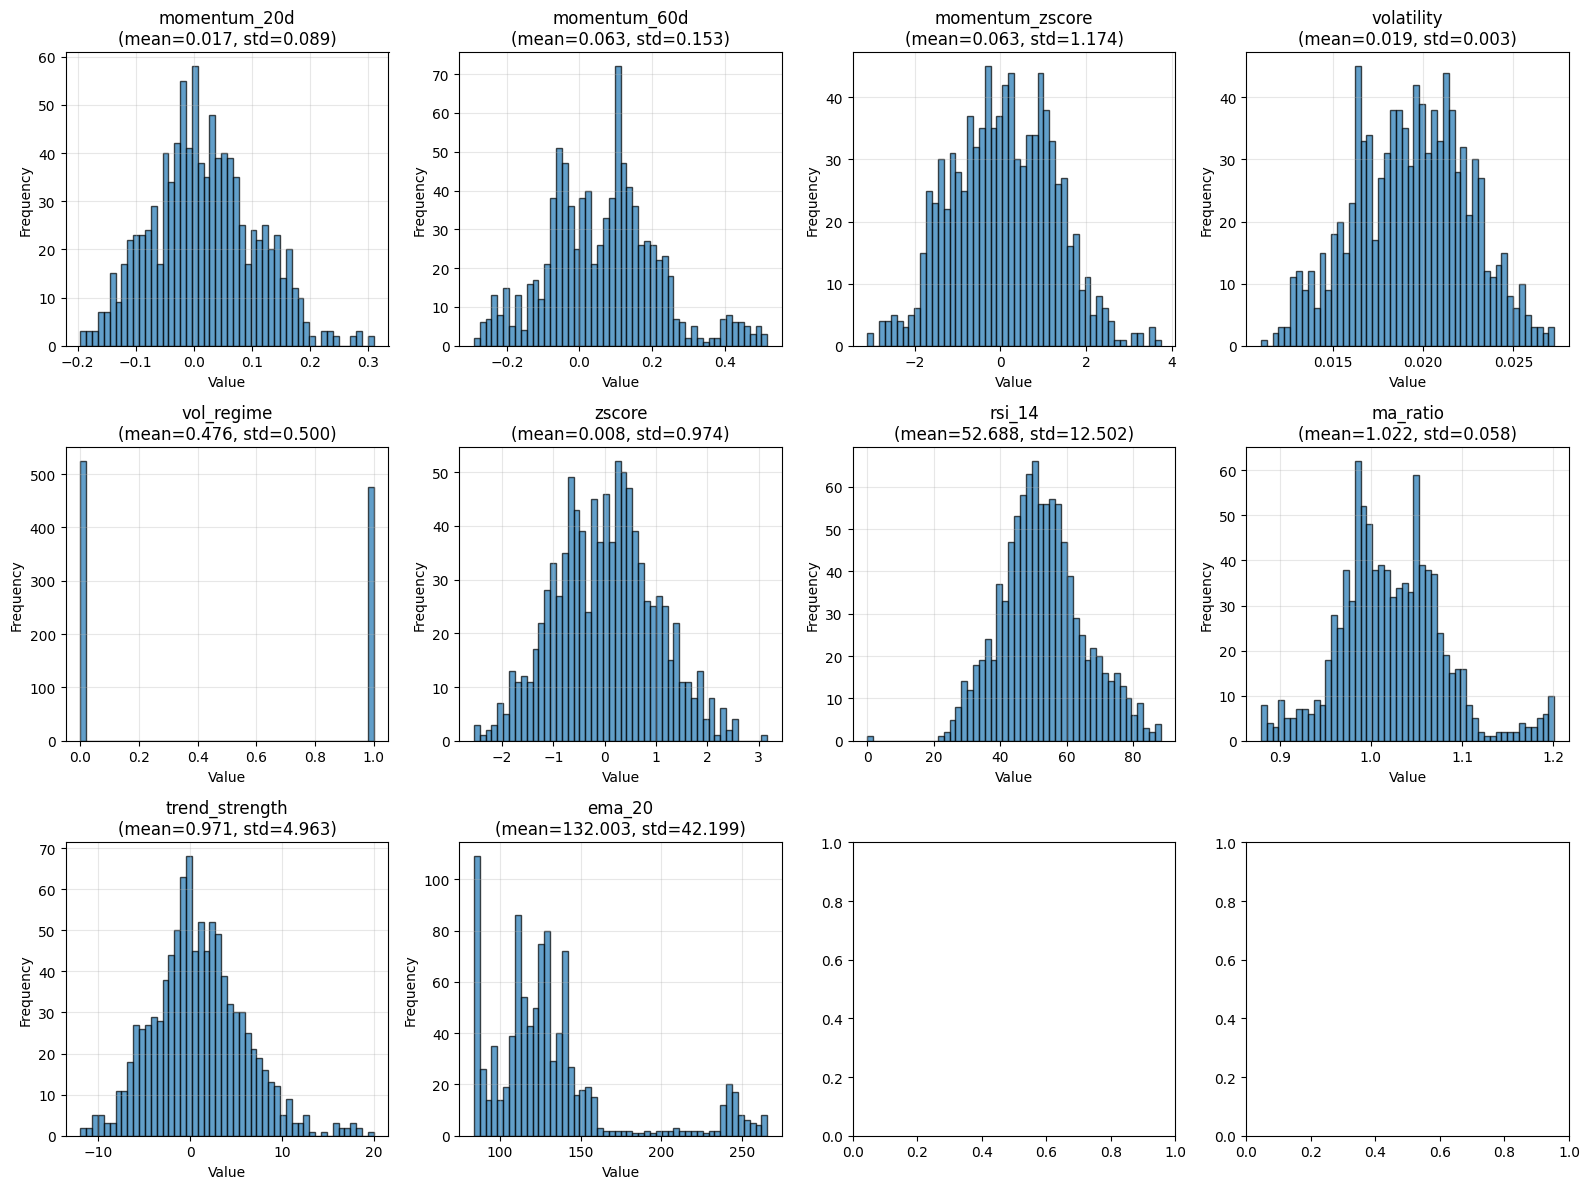

In [15]:
print("\n" + "=" * 80)
print("SECTION 3: FEATURE DISTRIBUTION ANALYSIS")
print("=" * 80)

# Summary statistics for each feature
print("\nFeature Summary Statistics (after NaN removal):")
print(features_df.describe().round(4))

# Plot distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(features_df.columns):
    ax = axes[idx]
    data = features_df[col].dropna()
    
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'{col}\n(mean={data.mean():.3f}, std={data.std():.3f})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: feature_distributions.png")
plt.show()

## Section 4: Stationarity Testing

Test each feature for stationarity using a simple variance-based heuristic.

In [16]:
print("\n" + "=" * 80)
print("SECTION 4: STATIONARITY TESTING")
print("=" * 80)

def simple_stationarity_test(series, name=''):
    """
    Simple stationarity check using variance of first vs second half.
    
    A simple heuristic: if the variance changes significantly between
    first half and second half, series is likely non-stationary.
    
    Returns: (is_stationary_estimate, variance_ratio)
    """
    data = series.dropna()
    mid = len(data) // 2
    
    var_first = data.iloc[:mid].var()
    var_second = data.iloc[mid:].var()
    
    # Variance ratio (should be ~1 for stationary series)
    var_ratio = var_first / var_second if var_second != 0 else np.inf
    
    # Simple heuristic: if ratio is between 0.5 and 2.0, consider stationary
    is_stationary = 0.5 < var_ratio < 2.0
    
    print(f"\n{name}:")
    print(f"  Variance (first half): {var_first:.6f}")
    print(f"  Variance (second half): {var_second:.6f}")
    print(f"  Variance Ratio: {var_ratio:.3f}")
    
    status = "✓ LIKELY STATIONARY" if is_stationary else "✗ LIKELY NON-STATIONARY"
    print(f"  Status: {status} (ratio should be ~1.0)")
    
    return is_stationary, var_ratio

# Test all features
print("\nStationarity Test Results:")
print("-" * 80)

adf_results = {}
for col in features_df.columns:
    is_stat, ratio = simple_stationarity_test(features_df[col], name=col)
    adf_results[col] = {'stationary': is_stat, 'ratio': ratio}

print("\n" + "-" * 80)
print("STATIONARITY SUMMARY:")
stationary_count = sum(1 for v in adf_results.values() if v['stationary'])
print(f"Stationary features: {stationary_count}/{len(adf_results)}")


SECTION 4: STATIONARITY TESTING

Stationarity Test Results:
--------------------------------------------------------------------------------

momentum_20d:
  Variance (first half): 0.006860
  Variance (second half): 0.008834
  Variance Ratio: 0.777
  Status: ✓ LIKELY STATIONARY (ratio should be ~1.0)

momentum_60d:
  Variance (first half): 0.013217
  Variance (second half): 0.033098
  Variance Ratio: 0.399
  Status: ✗ LIKELY NON-STATIONARY (ratio should be ~1.0)

momentum_zscore:
  Variance (first half): 1.212669
  Variance (second half): 1.538277
  Variance Ratio: 0.788
  Status: ✓ LIKELY STATIONARY (ratio should be ~1.0)

volatility:
  Variance (first half): 0.000012
  Variance (second half): 0.000008
  Variance Ratio: 1.490
  Status: ✓ LIKELY STATIONARY (ratio should be ~1.0)

vol_regime:
  Variance (first half): 0.248381
  Variance (second half): 0.250497
  Variance Ratio: 0.992
  Status: ✓ LIKELY STATIONARY (ratio should be ~1.0)

zscore:
  Variance (first half): 0.939770
  Varia

## Section 5: Feature Correlation & Redundancy

Analyze correlations between features to identify redundant features.


SECTION 5: FEATURE CORRELATION ANALYSIS

✓ Saved: feature_correlation.png


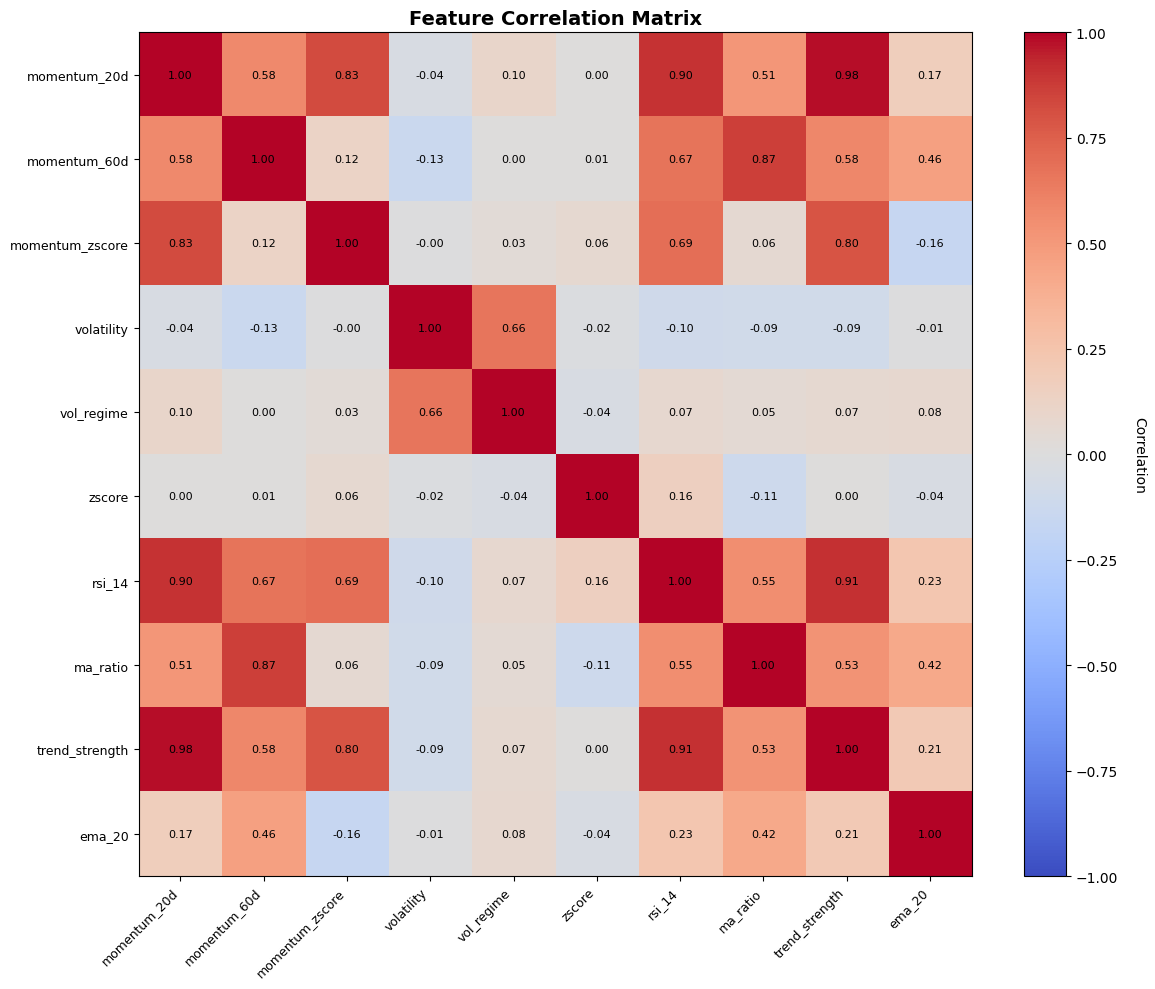


Highly Correlated Feature Pairs (|corr| > 0.8):
--------------------------------------------------------------------------------
momentum_20d         <-> momentum_zscore     : +0.828
momentum_20d         <-> rsi_14              : +0.901
momentum_20d         <-> trend_strength      : +0.983
momentum_60d         <-> ma_ratio            : +0.865
rsi_14               <-> trend_strength      : +0.911


In [17]:
print("\n" + "=" * 80)
print("SECTION 5: FEATURE CORRELATION ANALYSIS")
print("=" * 80)

corr_matrix = features_df.corr()

# Plot correlation heatmap using matplotlib
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation', rotation=270, labelpad=20)

# Add correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: feature_correlation.png")
plt.show()

# Find highly correlated pairs (potential redundancy)
print("\nHighly Correlated Feature Pairs (|corr| > 0.8):")
print("-" * 80)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            print(f"{corr_matrix.columns[i]:20s} <-> {corr_matrix.columns[j]:20s}: {corr_val:+.3f}")

## Section 6: Returns Analysis

Analyze the statistical properties of returns including distribution and normality tests.


SECTION 6: RETURNS ANALYSIS

Log Returns Statistics:
  Mean: 0.000877 (22.10% annualized)
  Std Dev: 0.019592 (31.10% annualized)
  Skewness: 0.1183
  Kurtosis: 0.0711
  Min: -0.064325
  Max: 0.077555

✓ Saved: returns_analysis.png


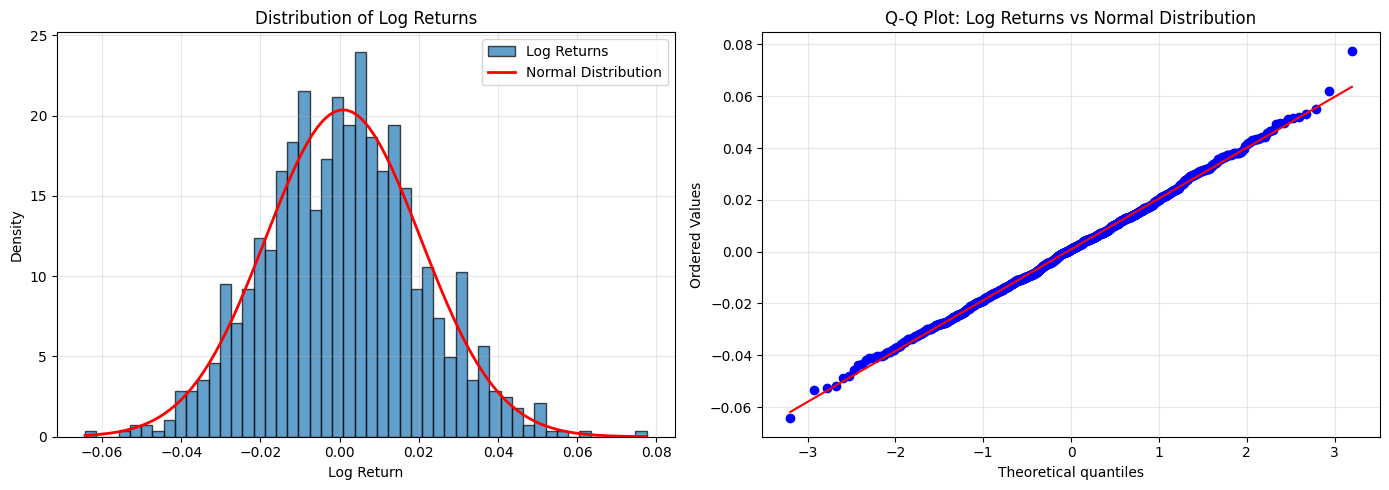

In [18]:
print("\n" + "=" * 80)
print("SECTION 6: RETURNS ANALYSIS")
print("=" * 80)

log_returns = compute_log_returns(price_series)
arith_returns = price_series.pct_change()

print(f"\nLog Returns Statistics:")
print(f"  Mean: {log_returns.mean():.6f} ({log_returns.mean()*252:.2%} annualized)")
print(f"  Std Dev: {log_returns.std():.6f} ({annualize_volatility(log_returns.std()):.2%} annualized)")
print(f"  Skewness: {log_returns.skew():.4f}")
print(f"  Kurtosis: {log_returns.kurtosis():.4f}")
print(f"  Min: {log_returns.min():.6f}")
print(f"  Max: {log_returns.max():.6f}")

# Log returns should be approximately normal for theoretical models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal distribution overlay
ax = axes[0]
data = log_returns.dropna()
ax.hist(data, bins=50, density=True, alpha=0.7, edgecolor='black', label='Log Returns')

# Overlay normal distribution
mu, sigma = data.mean(), data.std()
x = np.linspace(data.min(), data.max(), 100)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.set_title('Distribution of Log Returns')
ax.legend()
ax.grid(True, alpha=0.3)

# Q-Q plot
ax = axes[1]
stats.probplot(data, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Log Returns vs Normal Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('returns_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: returns_analysis.png")
plt.show()

## Section 7: Volatility Analysis

Examine rolling volatility and volatility regimes.


SECTION 7: VOLATILITY ANALYSIS

Volatility Statistics (20-day rolling):
  Mean: 0.019338 (30.70% annualized)
  Min: 0.010990 (17.45% annualized)
  Max: 0.027267 (43.29% annualized)

✓ Saved: volatility_analysis.png


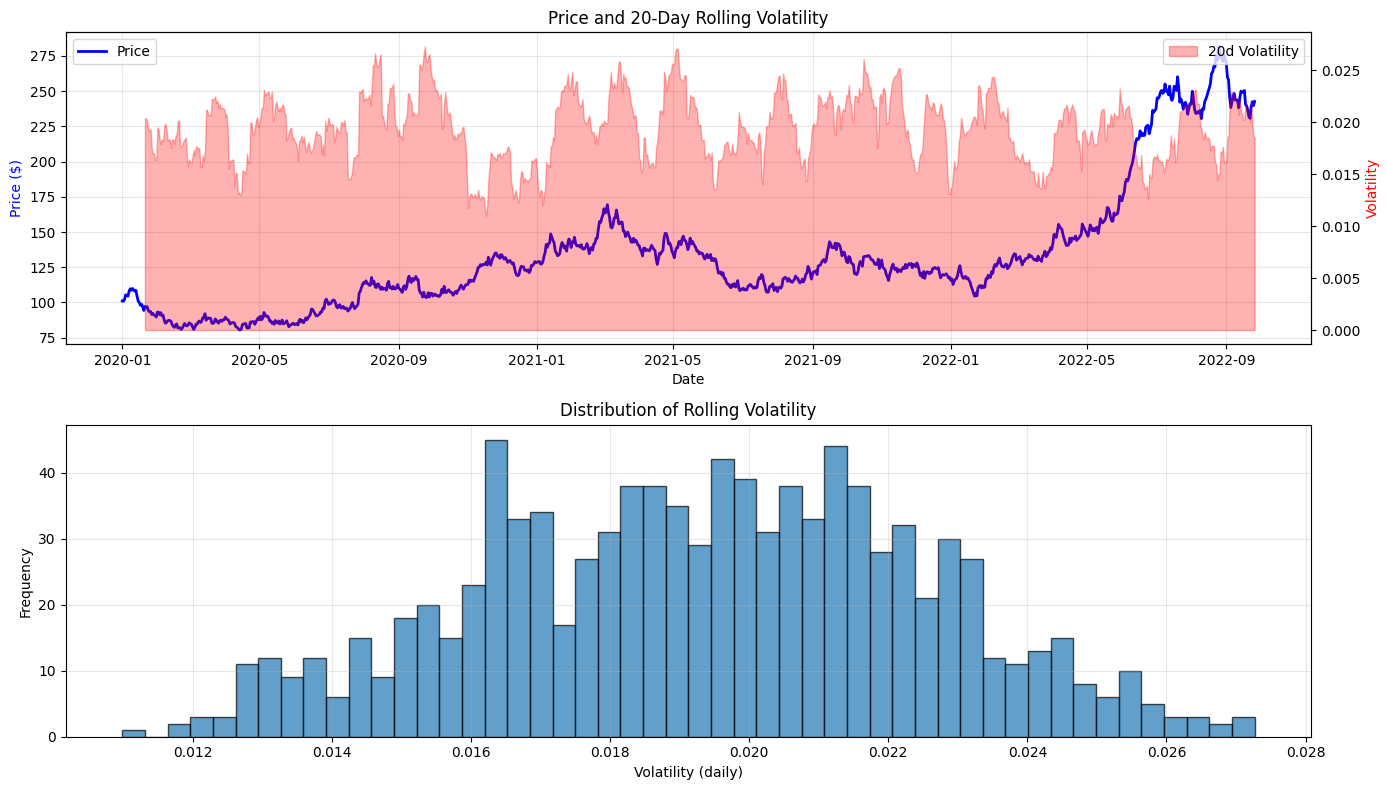

In [ ]:
print("\n" + "=" * 80)
print("SECTION 7: VOLATILITY ANALYSIS")
print("=" * 80)

rolling_vol = compute_rolling_volatility(log_returns, window=20)

print(f"\nVolatility Statistics (20-day rolling):")
print(f"  Mean: {rolling_vol.mean():.6f} ({annualize_volatility(rolling_vol.mean()):.2%} annualized)")
print(f"  Min: {rolling_vol.min():.6f} ({annualize_volatility(rolling_vol.min()):.2%} annualized)")
print(f"  Max: {rolling_vol.max():.6f} ({annualize_volatility(rolling_vol.max()):.2%} annualized)")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price and volatility regimes
ax = axes[0]
ax2 = ax.twinx()
ax.plot(price_series.index, price_series.to_numpy(), 'b-', linewidth=2, label='Price')
ax2.fill_between(rolling_vol.index, rolling_vol.to_numpy(), alpha=0.3, color='red', label='20d Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)', color='b')
ax2.set_ylabel('Volatility', color='r')
ax.set_title('Price and 20-Day Rolling Volatility')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# Volatility distribution
ax = axes[1]
ax.hist(rolling_vol.dropna(), bins=50, alpha=0.7, edgecolor='black')
ax.set_xlabel('Volatility (daily)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Rolling Volatility')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volatility_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: volatility_analysis.png")
plt.show()

## Section 8: Signal Generation & Basic Backtest

Generate trading signals based on features and visualize them.

In [20]:
print("\n" + "=" * 80)
print("SECTION 8: SIGNAL GENERATION")
print("=" * 80)

# Generate simple trading signals
signals = pd.DataFrame(index=features_df.index)

# Mean reversion signal (Z-score based)
signals['zscore'] = features_df['zscore']
signals['signal_mr'] = 0
signals.loc[signals['zscore'] < -1.5, 'signal_mr'] = 1   # Oversold → Buy
signals.loc[signals['zscore'] > 1.5, 'signal_mr'] = -1   # Overbought → Sell

# Momentum signal
signals['momentum'] = features_df['momentum_20d']
signals['signal_mom'] = 0
signals.loc[signals['momentum'] > 0, 'signal_mom'] = 1   # Positive momentum → Buy
signals.loc[signals['momentum'] < 0, 'signal_mom'] = -1  # Negative momentum → Sell

# RSI signal
signals['rsi'] = features_df['rsi_14']
signals['signal_rsi'] = 0
signals.loc[signals['rsi'] < 30, 'signal_rsi'] = 1    # Oversold → Buy
signals.loc[signals['rsi'] > 70, 'signal_rsi'] = -1   # Overbought → Sell

# Combined signal (simple majority voting)
signals['signal_combined'] = (
    signals['signal_mr'] + signals['signal_mom'] + signals['signal_rsi']
)
signals['signal_combined'] = np.sign(signals['signal_combined'])

print("\nSignal Counts:")
print(f"  Mean Reversion Buy signals:  {(signals['signal_mr'] == 1).sum()}")
print(f"  Mean Reversion Sell signals: {(signals['signal_mr'] == -1).sum()}")
print(f"  Momentum Buy signals:        {(signals['signal_mom'] == 1).sum()}")
print(f"  Momentum Sell signals:       {(signals['signal_mom'] == -1).sum()}")
print(f"  RSI Buy signals:             {(signals['signal_rsi'] == 1).sum()}")
print(f"  RSI Sell signals:            {(signals['signal_rsi'] == -1).sum()}")


SECTION 8: SIGNAL GENERATION

Signal Counts:
  Mean Reversion Buy signals:  58
  Mean Reversion Sell signals: 65
  Momentum Buy signals:        539
  Momentum Sell signals:       441
  RSI Buy signals:             31
  RSI Sell signals:            101



✓ Saved: trading_signals.png


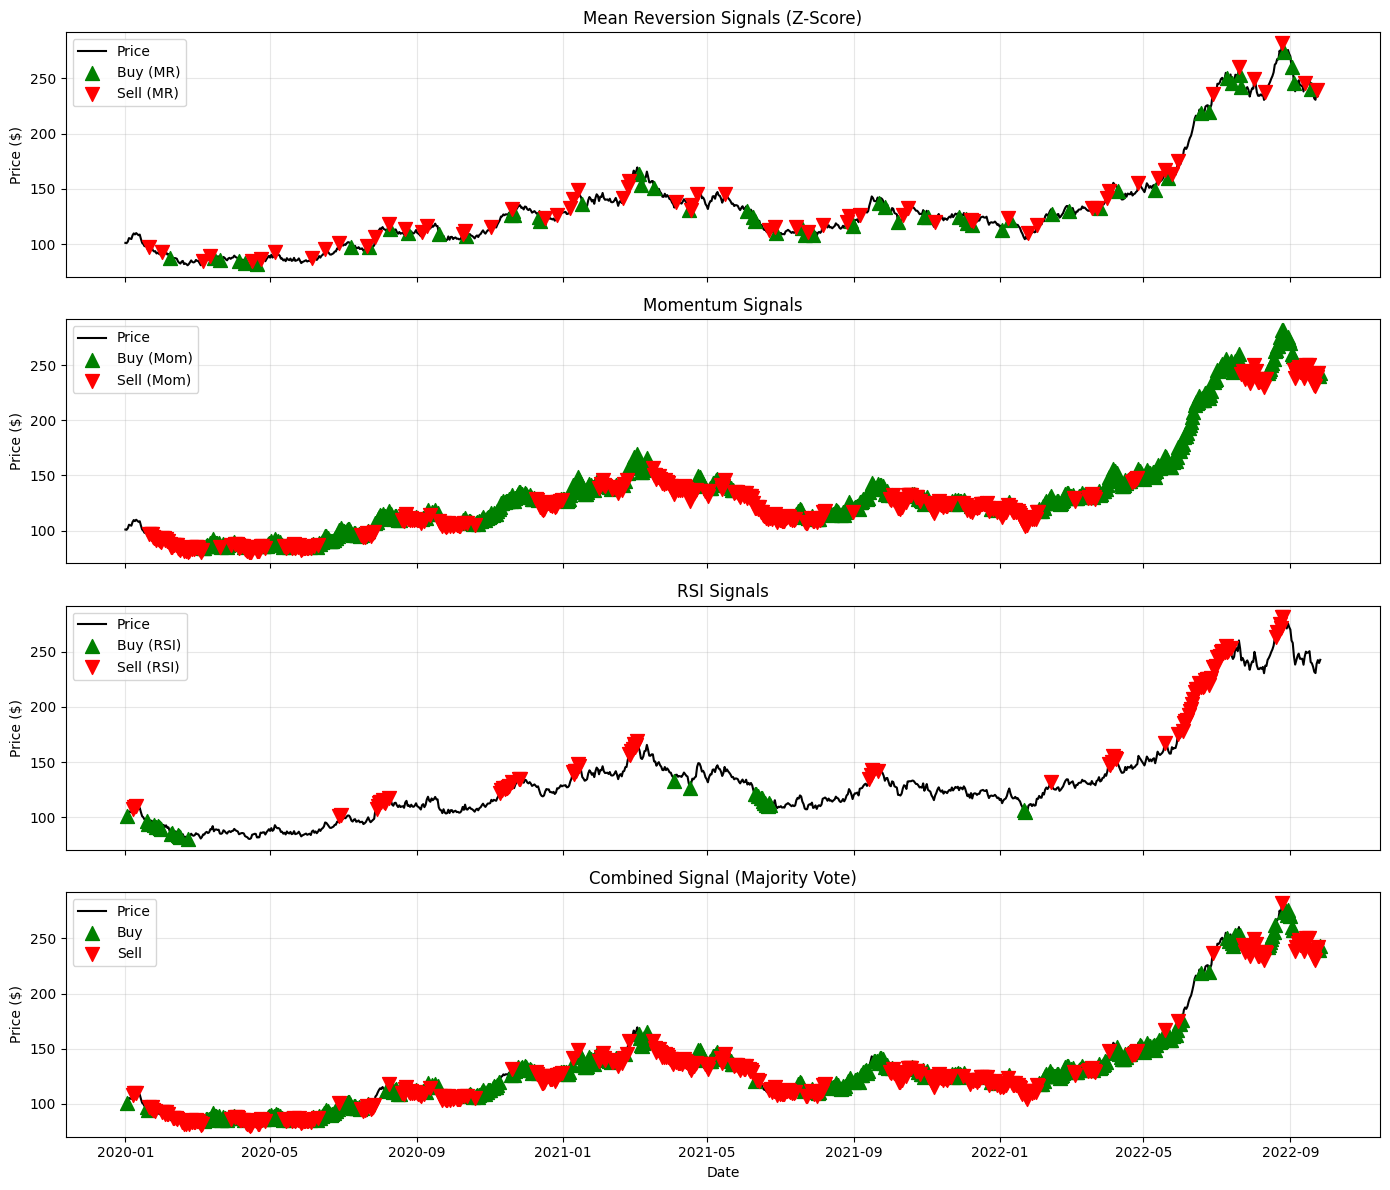

In [ ]:
# Plot signals
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price with mean reversion signals
ax = axes[0]
ax.plot(price_series.index, price_series.to_numpy(), 'k-', linewidth=1.5, label='Price')
buy_mr = signals[signals['signal_mr'] == 1]
sell_mr = signals[signals['signal_mr'] == -1]
ax.scatter(buy_mr.index, price_series[buy_mr.index], color='green', marker='^', s=100, label='Buy (MR)', zorder=5)
ax.scatter(sell_mr.index, price_series[sell_mr.index], color='red', marker='v', s=100, label='Sell (MR)', zorder=5)
ax.set_ylabel('Price ($)')
ax.set_title('Mean Reversion Signals (Z-Score)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Momentum signals
ax = axes[1]
ax.plot(price_series.index, price_series.to_numpy(), 'k-', linewidth=1.5, label='Price')
buy_mom = signals[signals['signal_mom'] == 1]
sell_mom = signals[signals['signal_mom'] == -1]
ax.scatter(buy_mom.index, price_series[buy_mom.index], color='green', marker='^', s=100, label='Buy (Mom)', zorder=5)
ax.scatter(sell_mom.index, price_series[sell_mom.index], color='red', marker='v', s=100, label='Sell (Mom)', zorder=5)
ax.set_ylabel('Price ($)')
ax.set_title('Momentum Signals')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# RSI signals
ax = axes[2]
ax.plot(price_series.index, price_series.to_numpy(), 'k-', linewidth=1.5, label='Price')
buy_rsi = signals[signals['signal_rsi'] == 1]
sell_rsi = signals[signals['signal_rsi'] == -1]
ax.scatter(buy_rsi.index, price_series[buy_rsi.index], color='green', marker='^', s=100, label='Buy (RSI)', zorder=5)
ax.scatter(sell_rsi.index, price_series[sell_rsi.index], color='red', marker='v', s=100, label='Sell (RSI)', zorder=5)
ax.set_ylabel('Price ($)')
ax.set_title('RSI Signals')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Combined signal
ax = axes[3]
ax.plot(price_series.index, price_series.to_numpy(), 'k-', linewidth=1.5, label='Price')
buy_comb = signals[signals['signal_combined'] == 1]
sell_comb = signals[signals['signal_combined'] == -1]
ax.scatter(buy_comb.index, price_series[buy_comb.index], color='green', marker='^', s=100, label='Buy', zorder=5)
ax.scatter(sell_comb.index, price_series[sell_comb.index], color='red', marker='v', s=100, label='Sell', zorder=5)
ax.set_ylabel('Price ($)')
ax.set_xlabel('Date')
ax.set_title('Combined Signal (Majority Vote)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trading_signals.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: trading_signals.png")
plt.show()

## Section 9: Summary & Key Findings

Summarize the analysis and provide key insights from the feature engineering process.

In [ ]:
print("\n" + "=" * 80)
print("SECTION 9: SUMMARY & KEY FINDINGS")
print("=" * 80)

print("\n📊 KEY FINDINGS:")
print("-" * 80)

print(f"\n1. FEATURES GENERATED: {len(features_df.columns)} features")
print(f"   - Stationary features: {stationary_count}/{len(adf_results)}")
print(f"   - Non-stationary features: {len(adf_results) - stationary_count}/{len(adf_results)}")

print(f"\n2. RETURNS CHARACTERISTICS:")
print(f"   - Annualized return: {log_returns.mean()*252:.2%}")
print(f"   - Annualized volatility: {annualize_volatility(log_returns.std()):.2%}")
print(f"   - Sharpe ratio (assuming 0% risk-free rate): {log_returns.mean()/log_returns.std() * np.sqrt(252):.2f}")

print(f"\n3. SIGNAL GENERATION:")
print(f"   - Mean reversion signals: {(signals['signal_mr'] != 0).sum()} total")
print(f"   - Momentum signals: {(signals['signal_mom'] != 0).sum()} total")
print(f"   - RSI signals: {(signals['signal_rsi'] != 0).sum()} total")
print(f"   - Combined signals: {(signals['signal_combined'] != 0).sum()} total")

print(f"\n4. FEATURE QUALITY:")
highly_corr_pairs = 0
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            highly_corr_pairs += 1
print(f"   - Highly correlated pairs (|corr| > 0.8): {highly_corr_pairs}")
print(f"   - Average correlation: {corr_matrix.to_numpy()[np.triu_indices_from(corr_matrix.to_numpy(), k=1)].mean():.3f}")

print("\n" + "=" * 80)
print("✓ FEATURE ENGINEERING COMPLETE")
print("=" * 80)
print("\nGenerated files:")
print("  1. feature_distributions.png - Distribution plots for all features")
print("  2. feature_correlation.png - Correlation matrix heatmap")
print("  3. returns_analysis.png - Returns distribution and Q-Q plot")
print("  4. volatility_analysis.png - Volatility time series and distribution")
print("  5. trading_signals.png - Signal generation visualization")

print("\nNext steps:")
print("  - Refine signal logic based on feature characteristics")
print("  - Implement proper backtesting framework")
print("  - Test feature importance for ML models")
print("  - Optimize parameters (windows, thresholds)")


SECTION 9: SUMMARY & KEY FINDINGS

📊 KEY FINDINGS:
--------------------------------------------------------------------------------

1. FEATURES GENERATED: 10 features
   - Stationary features: 7/10
   - Non-stationary features: 3/10

2. RETURNS CHARACTERISTICS:
   - Annualized return: 22.10%
   - Annualized volatility: 31.10%
   - Sharpe ratio (assuming 0% risk-free rate): 0.71

3. SIGNAL GENERATION:
   - Mean reversion signals: 123 total
   - Momentum signals: 980 total
   - RSI signals: 132 total
   - Combined signals: 821 total

4. FEATURE QUALITY:
   - Highly correlated pairs (|corr| > 0.8): 5
   - Average correlation: 0.256

✓ FEATURE ENGINEERING COMPLETE

Generated files:
  1. feature_distributions.png - Distribution plots for all features
  2. feature_correlation.png - Correlation matrix heatmap
  3. returns_analysis.png - Returns distribution and Q-Q plot
  4. volatility_analysis.png - Volatility time series and distribution
  5. trading_signals.png - Signal generation visual